<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/Google_Trends_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install dependencies (run in Colab or terminal)

In [12]:
!pip install pytrends pandas matplotlib statsmodels

IMPORTS

In [13]:
from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

SETUP

In [14]:
pytrends = TrendReq(hl='en-US', tz=360)

Keywords for analysis

In [15]:
keywords = ["Christmas", "Black Friday", "FIFA"]

Fetch data for the last 5 years

In [16]:
pytrends.build_payload(keywords, timeframe='2018-08-01 2023-08-01', geo='')

Interest over time

In [17]:
data = pytrends.interest_over_time()

Remove 'isPartial' column

In [19]:
if 'isPartial' in data.columns:
    data = data.drop(columns=['isPartial'])

print(data.head())

            Christmas  Black Friday  FIFA
date                                     
2018-07-29          2             0     4
2018-08-05          2             0     4
2018-08-12          2             0     4
2018-08-19          3             0     4
2018-08-26          3             0     4


PLOT TRENDS

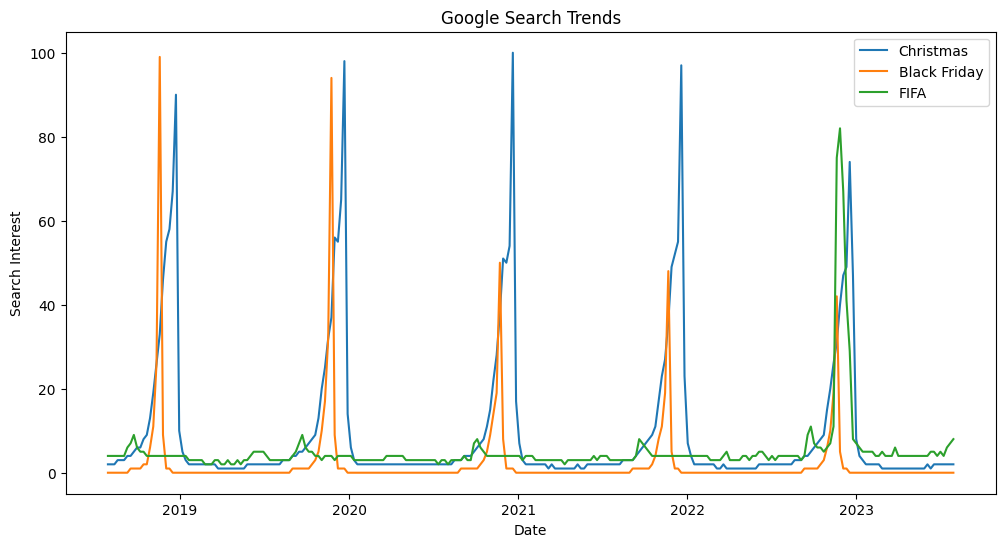

In [20]:
plt.figure(figsize=(12,6))
for kw in keywords:
    plt.plot(data.index, data[kw], label=kw)

plt.title("Google Search Trends")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.legend()
plt.show()

SEASONAL DECOMPOSITION


--- Seasonal Decomposition for Christmas ---


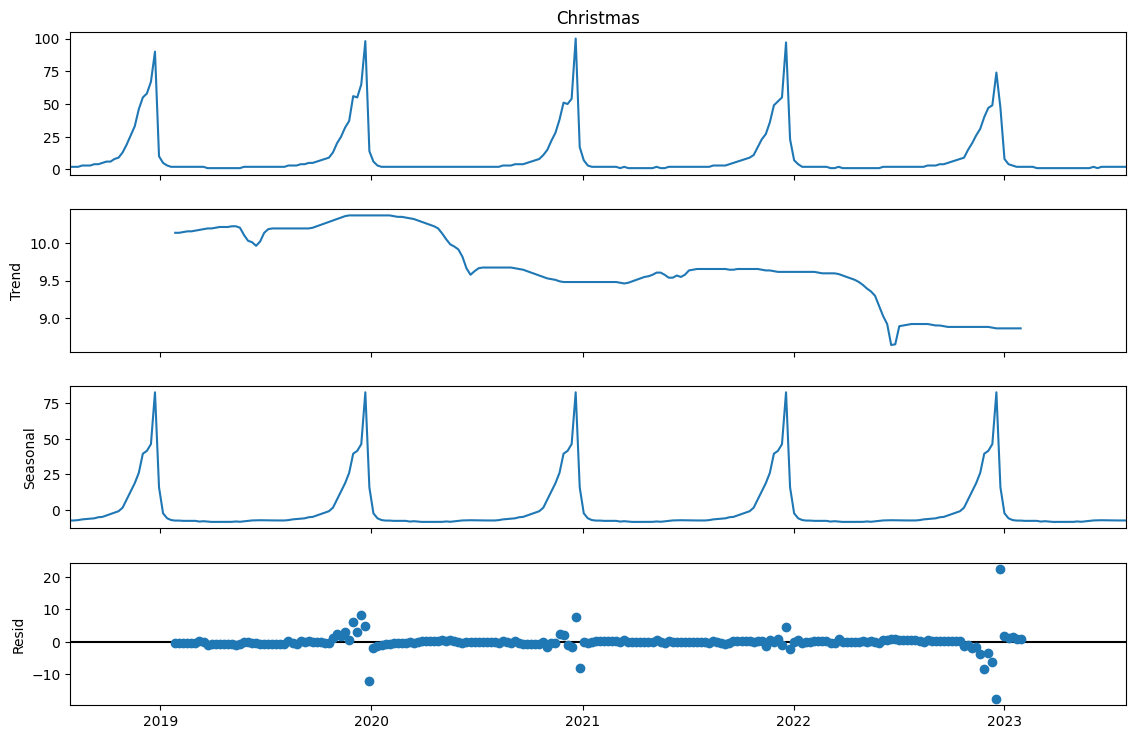


--- Seasonal Decomposition for Black Friday ---


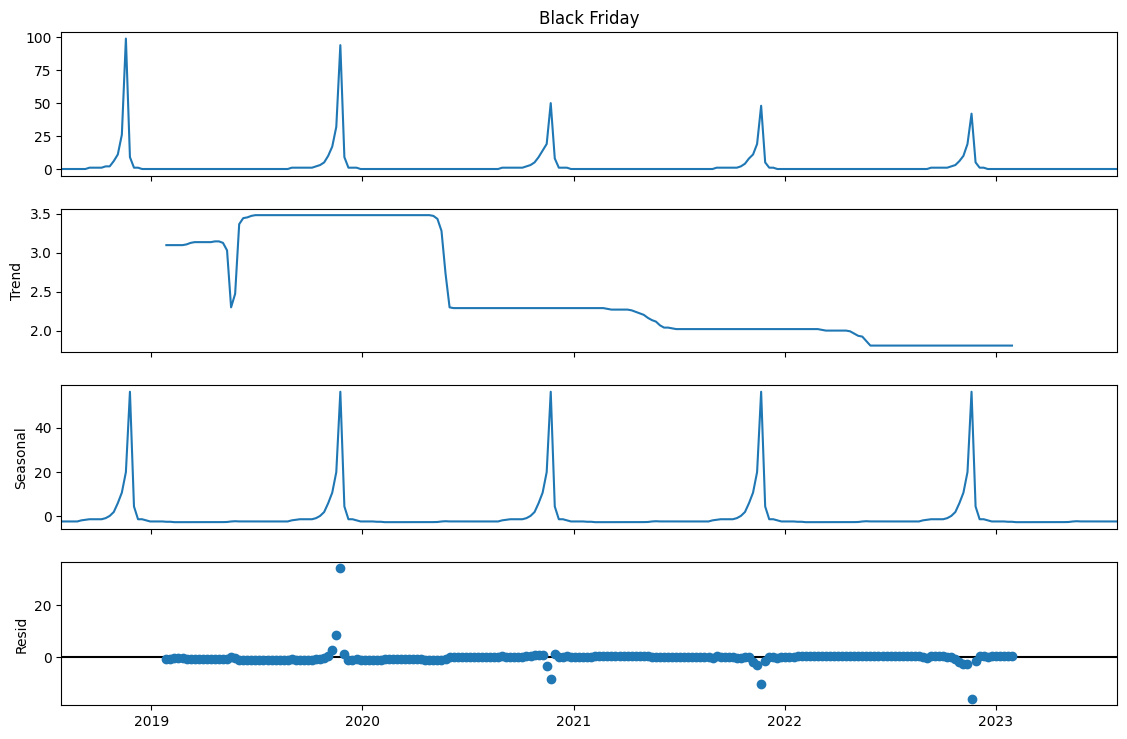


--- Seasonal Decomposition for FIFA ---


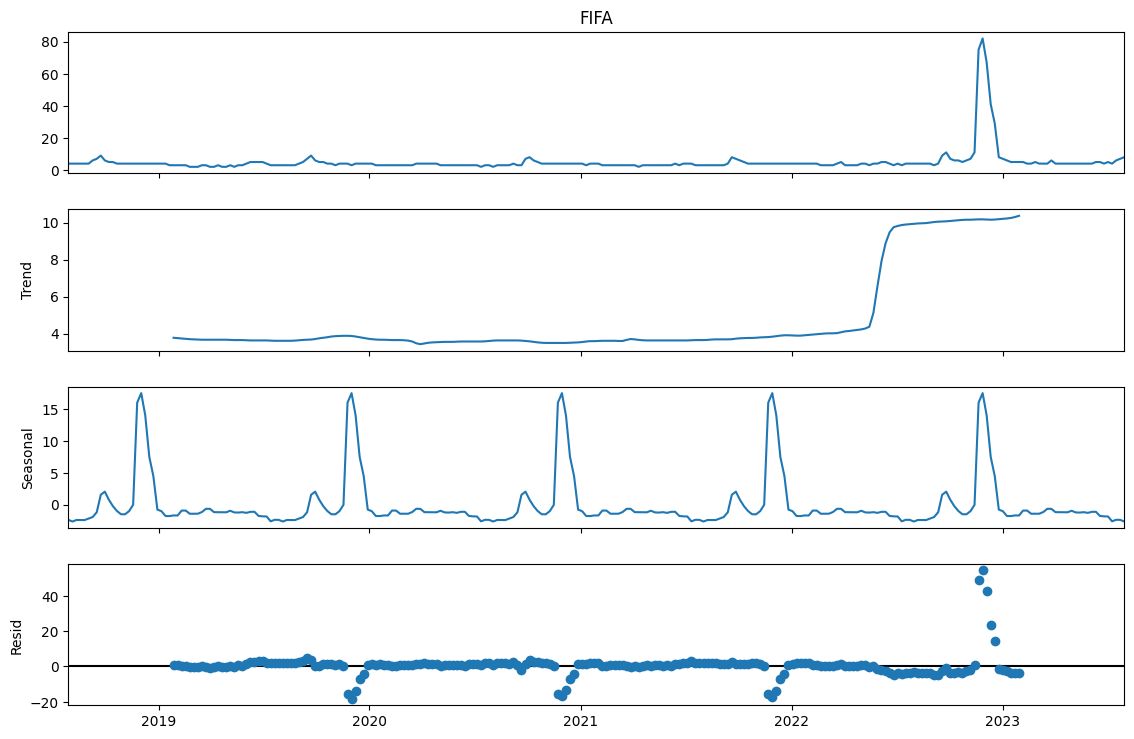

In [22]:
for kw in keywords:
    print(f"\n--- Seasonal Decomposition for {kw} ---")
    decomposition = seasonal_decompose(data[kw], model='additive', period=52)  # Weekly data, yearly seasonality
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.show()